In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"D:\shopping_trends.csv")
print(df)

      Customer ID  Age  Gender Item Purchased     Category  \
0               1   55    Male         Blouse     Clothing   
1               2   19    Male        Sweater     Clothing   
2               3   50    Male          Jeans     Clothing   
3               4   21    Male        Sandals     Footwear   
4               5   45    Male         Blouse     Clothing   
...           ...  ...     ...            ...          ...   
3895         3896   40  Female         Hoodie     Clothing   
3896         3897   52  Female       Backpack  Accessories   
3897         3898   46  Female           Belt  Accessories   
3898         3899   44  Female          Shoes     Footwear   
3899         3900   52  Female        Handbag  Accessories   

      Purchase Amount (USD)       Location Size      Color  Season  \
0                        53       Kentucky    L       Gray  Winter   
1                        64          Maine    L     Maroon  Winter   
2                        73  Massachusetts   

In [3]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               3900 non-null   int64  
 1   Age                       3900 non-null   int64  
 2   Gender                    3900 non-null   object 
 3   Item Purchased            3900 non-null   object 
 4   Category                  3900 non-null   object 
 5   Purchase Amount (USD)     3900 non-null   int64  
 6   Location                  3900 non-null   object 
 7   Size                      3900 non-null   object 
 8   Color                     3900 non-null   object 
 9   Season                    3900 non-null   object 
 10  Review Rating             3900 non-null   float64
 11  Subscription Status       3900 non-null   object 
 12  Payment Method            3900 non-null   object 
 13  Shipping Type             3900 non-null   object 
 14  Discount

In [5]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538
std,1125.977353,15.207589,23.685392,0.716223,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.isnull().sum()

Customer ID                 0
Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)       0
Location                    0
Size                        0
Color                       0
Season                      0
Review Rating               0
Subscription Status         0
Payment Method              0
Shipping Type               0
Discount Applied            0
Promo Code Used             0
Previous Purchases          0
Preferred Payment Method    0
Frequency of Purchases      0
dtype: int64

In [8]:
df.shape

(3900, 19)

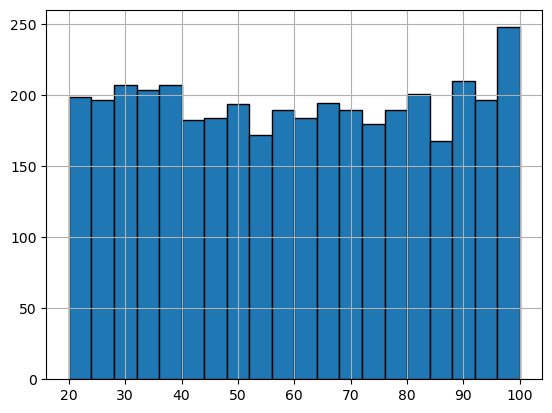

In [9]:
df["Purchase Amount (USD)"].hist(bins=20, edgecolor="black")
plt.show()

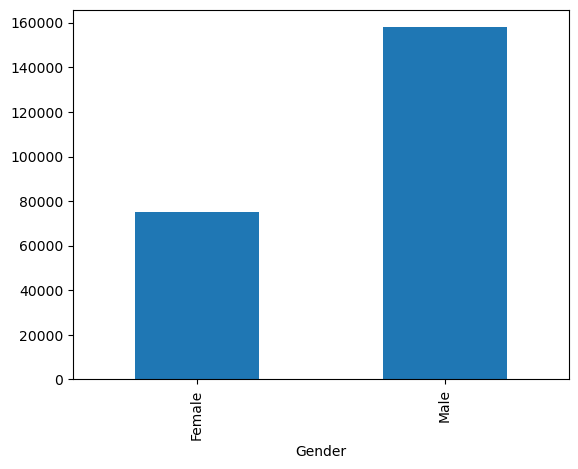

In [10]:
df.groupby("Gender")["Purchase Amount (USD)"].sum().plot(kind="bar")
plt.show()

In [11]:
df.groupby("Category")["Purchase Amount (USD)"].agg(["sum", "mean"]).sort_values(by="sum", ascending=False)

,sum,mean
Category,,
Clothing,104264,60.025331
Accessories,74200,59.838710
Footwear,36093,60.255426
Outerwear,18524,57.172840


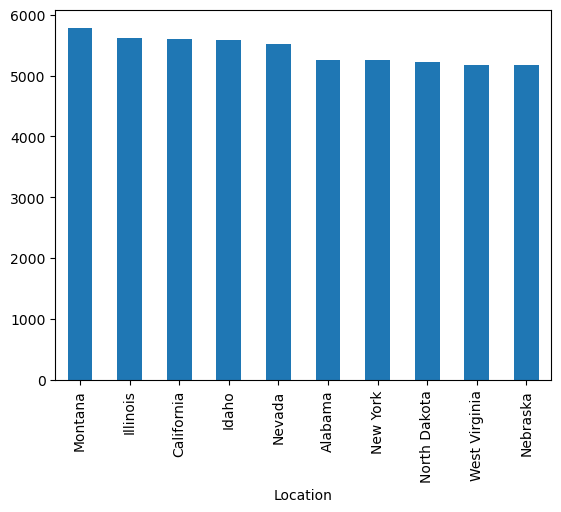

In [12]:
df.groupby("Location")["Purchase Amount (USD)"].sum().sort_values(ascending=False).head(10).plot(kind="bar")
plt.show()

In [13]:
df.groupby("Subscription Status")["Purchase Amount (USD)"].mean()

Subscription Status
No     59.865121
Yes    59.491928
Name: Purchase Amount (USD), dtype: float64

In [14]:
df.groupby("Discount Applied")["Review Rating"].mean()

Discount Applied
No     3.757715
Yes    3.739654
Name: Review Rating, dtype: float64

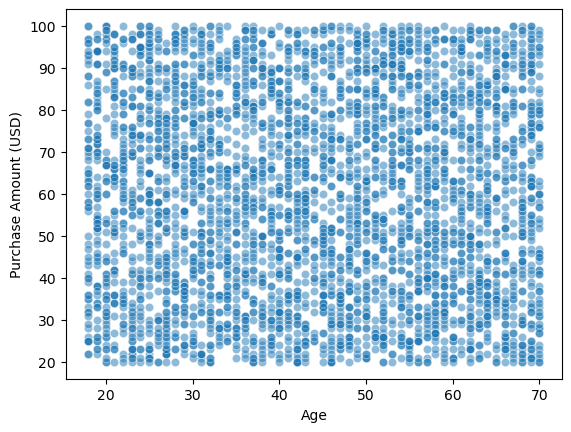

In [15]:
sns.scatterplot(data=df, x="Age", y="Purchase Amount (USD)", alpha=0.5)
plt.show()

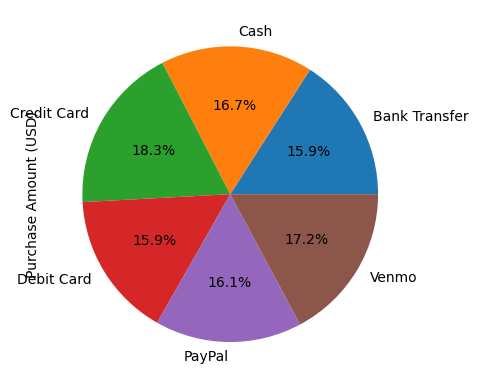

In [16]:
df.groupby("Payment Method")["Purchase Amount (USD)"].sum().plot(kind="pie", autopct="%1.1f%%")
plt.show()

In [17]:
df.groupby("Frequency of Purchases")["Purchase Amount (USD)"].mean().sort_values(ascending=False)

Frequency of Purchases
Bi-Weekly         60.694698
Annually          60.173077
Every 3 Months    60.082192
Quarterly         59.984014
Monthly           59.330922
Fortnightly       59.053506
Weekly            58.972171
Name: Purchase Amount (USD), dtype: float64

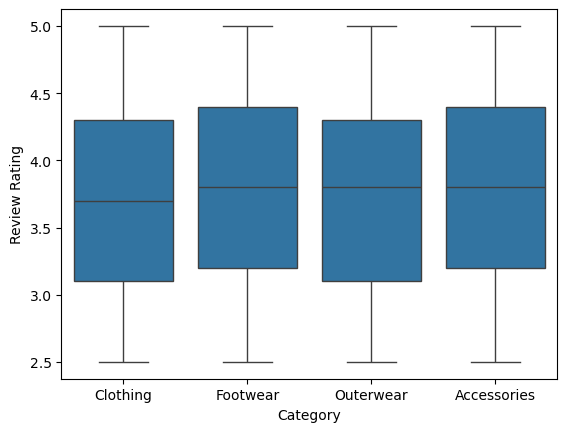

In [18]:
sns.boxplot(data=df, x="Category", y="Review Rating")
plt.show()

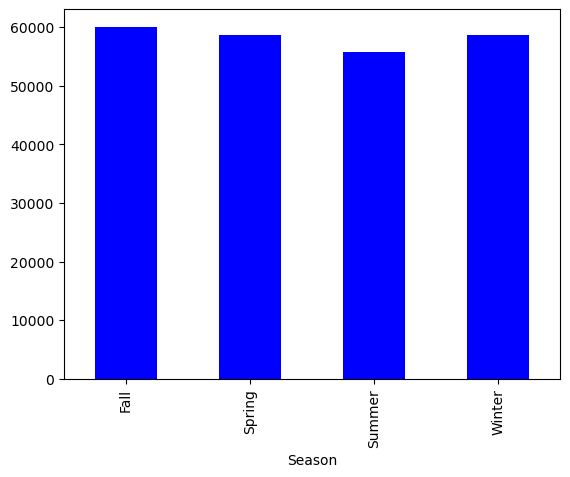

In [19]:
df.groupby("Season")["Purchase Amount (USD)"].sum().plot(kind="bar", color="blue")
plt.show()

In [20]:
df.groupby("Promo Code Used")["Purchase Amount (USD)"].mean()

Promo Code Used
No     60.130454
Yes    59.279070
Name: Purchase Amount (USD), dtype: float64

In [21]:
df.groupby("Shipping Type")["Review Rating"].mean()

Shipping Type
2-Day Shipping    3.761085
Express           3.776935
Free Shipping     3.717926
Next Day Air      3.720833
Standard          3.817737
Store Pickup      3.706462
Name: Review Rating, dtype: float64

In [22]:
df.groupby("Subscription Status")["Frequency of Purchases"].value_counts(normalize=True).unstack()

Frequency of Purchases,Annually,Bi-Weekly,Every 3 Months,Fortnightly,Monthly,Quarterly,Weekly
Subscription Status,,,,,,,
No,0.144714,0.142957,0.151036,0.136635,0.141904,0.148577,0.134176
Yes,0.151947,0.132953,0.146249,0.145299,0.141500,0.132953,0.149098


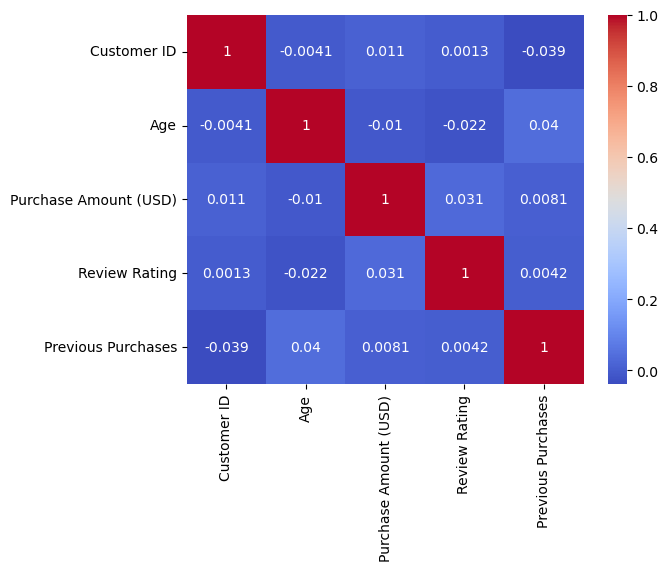

In [25]:
sns.heatmap(df.select_dtypes(include=["int64", "float64"]).corr(), annot=True, cmap="coolwarm")
plt.show()

In [24]:
print("Key Business Summary: Focus marketing on top seasons, fix low-rated categories, and push subscriptions.")

Key Business Summary: Focus marketing on top seasons, fix low-rated categories, and push subscriptions.


## Final Business Insights Report

### 1. Key Trends
* **Seasonal Demand:** Sales peak during specific seasons, showing when customer demand is highest.
* **Subscription Consistency:** Regular buyers and subscribers show similar shopping frequencies, meaning the customer base is stable.

### 2. Business Risks
* **Low Ratings vs. Shipping:** Slower or cheaper shipping options correlate with lower review ratings, risking customer loyalty.
* **Discount Dilution:** Giving too many discounts hasn't significantly increased the average purchase amount, risking profit margins.

### 3. Growth Opportunities
* **Targeted Marketing:** Double down on marketing campaigns during high-performing seasons to maximize revenue.
* **Premium Shipping Push:** Encourage customers to upgrade to faster shipping options to improve overall review ratings and customer satisfaction.